In [1]:

import tensorflow as tf
import tensorflow.keras.layers as tfl
import numpy as np
import matplotlib.pyplot as plt
import os
import datetime
import scipy.io
import tarfile
import urllib.request


In [2]:

# Download and extract dataset manually
url = "https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/static/wiki_crop.tar"
file_path = tf.keras.utils.get_file("wiki_crop.tar", origin=url, extract=False)


In [3]:

# Extract using tarfile
with tarfile.open(file_path, "r:") as tar:
    tar.extractall(path=os.path.dirname(file_path))


C:\Users\karth\AppData\Local\Temp\ipykernel_22496\2655080839.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=os.path.dirname(file_path))


In [4]:

# Dataset path
dataset_dir = os.path.join(os.path.dirname(file_path), 'wiki_crop')


In [5]:

# Load .mat file
mat = scipy.io.loadmat(os.path.join(dataset_dir, 'wiki.mat'))


In [6]:

# Extract age labels
dob = np.vectorize(lambda x: datetime.datetime.fromordinal(x).year)(
    mat["wiki"]["dob"][0][0][0]
)
photo_taken = mat["wiki"]["photo_taken"][0][0][0]
age = (photo_taken - dob).astype(np.float32)


In [7]:

# File paths
file_path = np.vectorize(lambda x: os.path.join(dataset_dir, x[0]))(
    mat["wiki"]["full_path"][0][0][0]
)


In [8]:

# Build TensorFlow dataset
file_age_ds = tf.data.Dataset.from_tensor_slices((file_path, age))

def parse_function(filename, label):
    image_string = tf.io.read_file(filename)
    image_decoded = tf.io.decode_jpeg(image_string, channels=1)
    image = tf.image.resize(image_decoded, [256, 256])
    return image, tf.expand_dims(label, 0)

image_age_ds = file_age_ds.map(parse_function).shuffle(seed=2, buffer_size=64)


In [9]:

# Split dataset
dataset_size = image_age_ds.cardinality().numpy()
AUTOTUNE = tf.data.AUTOTUNE
train_ds = image_age_ds.take(int(dataset_size * 0.6)).batch(32).prefetch(AUTOTUNE)
val_ds = image_age_ds.skip(int(dataset_size * 0.6)).take(int(dataset_size * 0.2)).batch(32).prefetch(AUTOTUNE)
test_ds = image_age_ds.skip(int(dataset_size * 0.8)).batch(32).prefetch(AUTOTUNE)


In [10]:

# Define model
model = tf.keras.Sequential([
    tfl.Conv2D(32, (7, 7), padding="valid", activation="relu", input_shape=(256, 256, 1)),
    tfl.MaxPool2D((4, 4), strides=4),
    tfl.Conv2D(64, (3, 3), padding="valid", activation="relu"),
    tfl.MaxPool2D((4, 4), strides=4),
    tfl.Conv2D(128, (3, 3), padding="valid", activation="relu"),
    tfl.MaxPool2D((2, 2), strides=2),
    tfl.Conv2D(256, (1, 1), padding="valid", activation="relu"),
    tfl.MaxPool2D((2, 2), strides=2),
    tfl.Flatten(),
    tfl.Dense(64, activation="relu"),
    tfl.Dense(1)
])

model.summary()


C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 250, 250, 32)   │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,561 (1.05 MB)

 Trainable params: 274,561 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:

# Compile
model.compile(optimizer='adam',
            loss=tf.keras.losses.MeanAbsoluteError(),
            metrics=['MAE'])


In [ ]:
# increase the number of epochs to 10 for better training results (Karthi)
# for time constraints, I will keep it to 1 epoch for now (karthi)
# Train
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=1,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir="logs")]
)


1169/1169 ━━━━━━━━━━━━━━━━━━━━ 328s 278ms/step - MAE: 15.7488 - loss: 15.7488 - val_MAE: 12.5495 - val_loss: 12.5495


In [13]:

# Evaluate
loss, accuracy = model.evaluate(test_ds)
print("Loss:", loss)
print("MAE:", accuracy)


390/390 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - MAE: 12.6186 - loss: 12.6186
Loss: 12.879034996032715
MAE: 12.879034996032715


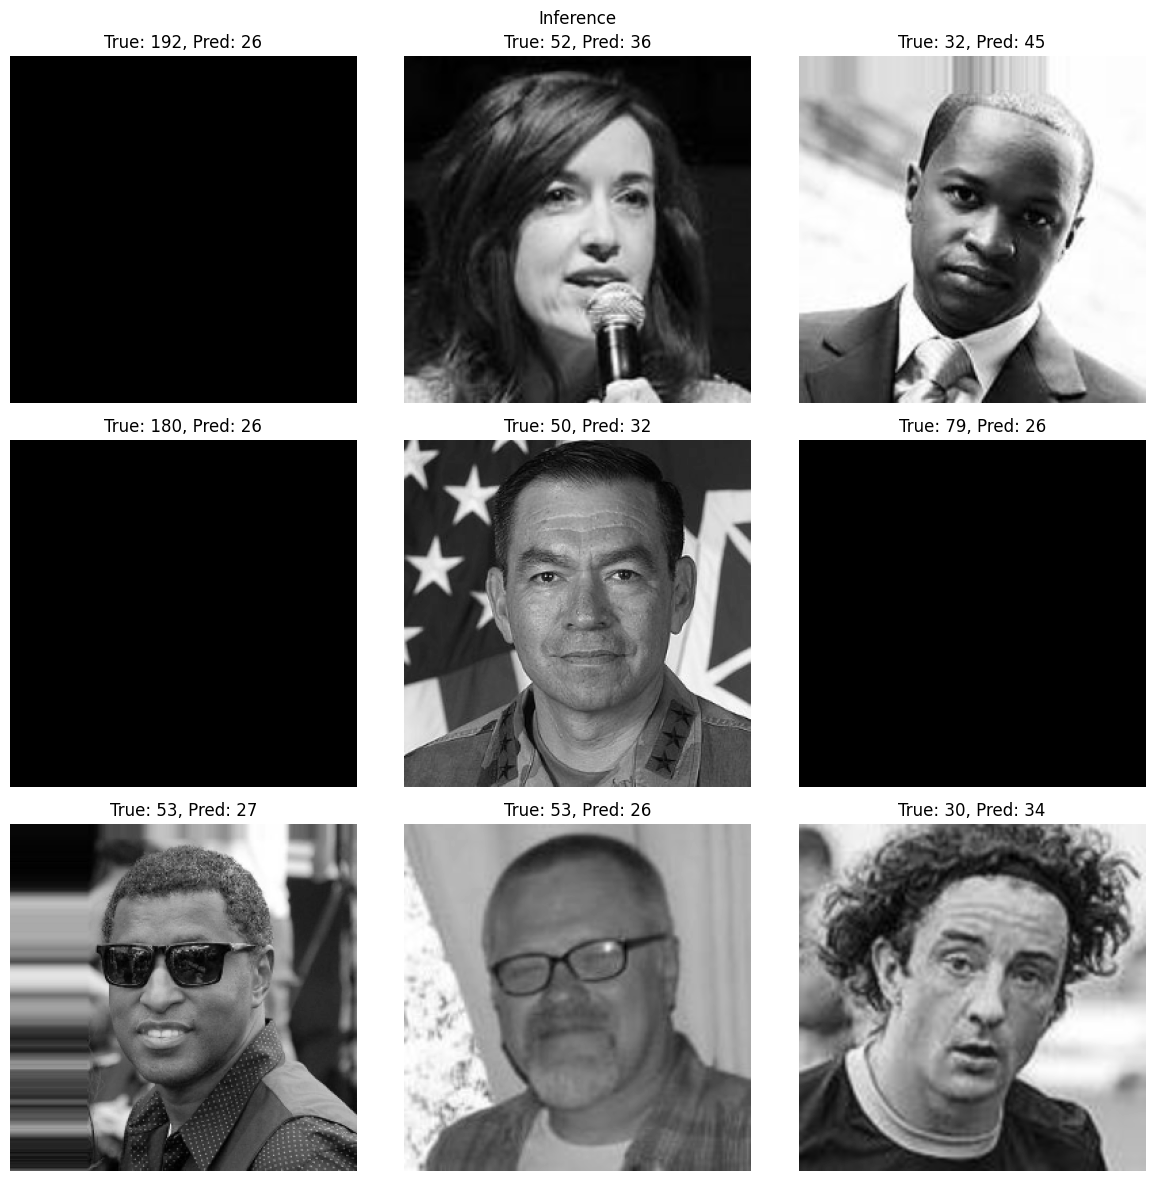

In [14]:

# Visualization
image_batch, label_batch = next(iter(val_ds))
predictions = tf.squeeze(model(image_batch))
label_batch = tf.squeeze(label_batch)

plt.figure(figsize=(12, 12))
plt.suptitle("Inference")
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.title(f"True: {label_batch[i]:.0f}, Pred: {predictions[i]:.0f}")
    plt.imshow(tf.squeeze(image_batch[i]), cmap='gray')
    plt.axis("off")
plt.tight_layout()
plt.show()